## Methods of Machine Learning (MAT 3373 A00) Short Homework Assignment 1
### Alex Hills 300241757

In [32]:
# Python imports:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import sklearn
from sklearn.linear_model import LinearRegression
import numpy as np

# Setting up the dataframes for SchoolA.csv, SchoolB.csv and SchoolC.csv
school_a = pd.read_csv("CSV_Files/SchoolA.csv", names=["IQ", "Diligence"], header=0)
school_b = pd.read_csv("CSV_Files/SchoolB.csv", names=["IQ", "Diligence"], header=0)
school_c = pd.read_csv("CSV_Files/SchoolC.csv", names=["IQ", "Diligence"], header=0)

***

## Part 1

***


### 1.1: Hypothesis test for β1:  
Null Hypothesis: $H_0:\beta_1 = 0$  
Alt. Hypothesis: $H_1:\beta_1 \neq 0$

Where $H_0$ corresponds to there being no linear relationship between IQ scores and diligence, and $H_1$ being that there is some linear relationship, positive or negative.

Then the test-statistic is:  $t=\frac{\hat\beta_1}{SE(\hat\beta_1)}$  

Which we input into the student's t-distribution with $n-2$ degrees of freedom (in this case, $n\approx50000$) to get the p-value, however we will use Python to compute this value rather than computing by hand. 

### 1.2: Fitting the Model:

In [33]:
# Fitting the model (using sklearn)

x = school_a[["IQ"]]
y = school_a["Diligence"]
fit = LinearRegression()
fit.fit(x,y)

# Printing some relevant values (slope+intercept)
print("Slope (beta_1):",fit.coef_)
print("Intercept (beta_0):",fit.intercept_)

Slope (beta_1): [-0.5545756]
Intercept (beta_0): 173.42780332359126


Text(0.5, 1.0, 'Diligence Score vs IQ (School A)')

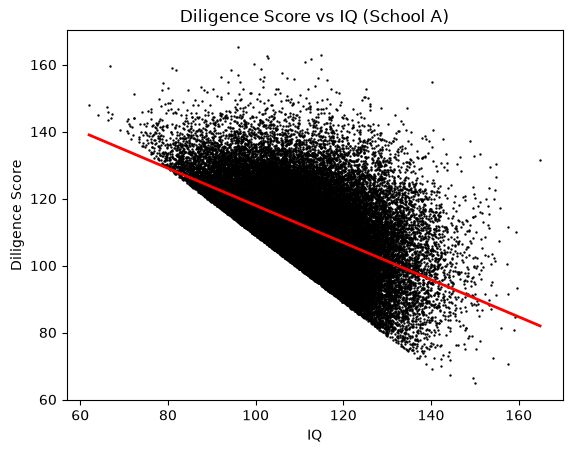

In [34]:
# Plotting the regression. I don't know if this is required but it is useful

x_grid = pd.DataFrame({
    "IQ": np.linspace(x.iloc[:, 0].min(), x.iloc[:, 0].max(), 200)
})

plt.scatter(x["IQ"], y, s=0.5,color="black") # Draws the individual observations 
plt.plot(x_grid["IQ"], fit.predict(x_grid), color="red",linewidth=2) # Draws the fitted regression line
plt.xlabel("IQ")
plt.ylabel("Diligence Score")
plt.title("Diligence Score vs IQ (School A)")

In [35]:
# Calculating the p-value and determining the results of the hypothesis test (using scipy)

# by default, this is a two-tailed test with H0: beta_1 = 0, so there is nothing to change for our purposes
result_a = stats.linregress(school_a["IQ"], school_a["Diligence"]) 
print("p-value:", result_a.pvalue)

p-value: 0.0


***

#### Hypothesis Test Conclusion
Therefore there is very strong evidence ($p-value\ll0.05$) to suggest a linear relationship between IQ and diligence in School A, enough to reject the null hypothesis (specifically a negative relationship, though our alternative hypothesis was only that there is some relationship, either positive or negative). 

Note: while the computed p-value above reads as 0.0, that does not literally mean a p-value of 0, only that the computed value is so small that SciPy returns it as 0.

***

### 1.3: Plotting the residuals

To check the normality of the residuals, I used both a histogram and a normal Q-Q plot. The histogram, superimposed with a true normal distribution based on the sample mean and standard deviation, provides an intuitive visual evaluation of the overall shape of the data. The Q-Q plot, meanwhile, allows for more precise analysis.

Text(0.5, 1.0, 'Histogram of Residuals From the Linear Fit (School A)')

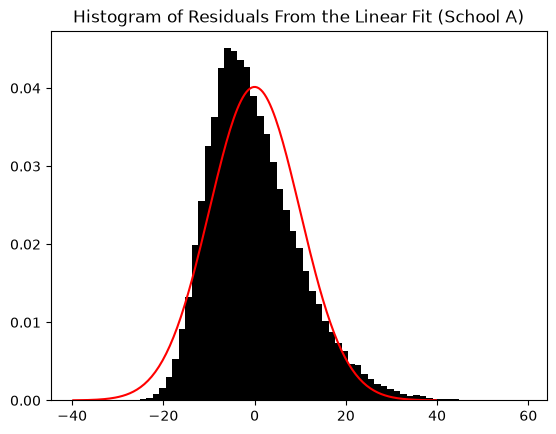

In [36]:
# Plotting the residuals (with a histogram)

fitted_values = fit.predict(x) 
residuals = y - fitted_values # e_i = yhat_i - y_i

# using the residuals' sample mean and sd for the parameters of the true normal distribution
mu = np.mean(residuals)
sigma = np.std(residuals)

grid = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 200)

plt.hist(residuals, bins=60, density=True, color="black")
plt.plot(grid, stats.norm.pdf(grid, mu, sigma), color="red")
plt.title("Histogram of Residuals From the Linear Fit (School A)")

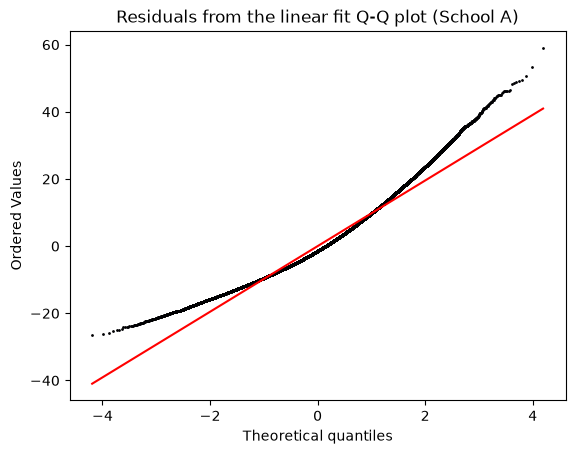

In [ ]:
# Creating a Q-Q plot for the residuals. 

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Residuals from the linear fit Q-Q plot (School A)")

# Accesses scatter points component of the QQ-plot (just to customize them to match the design of my other plots lol)
points_line = plt.gca().get_lines()[0]  # index 0 is the scatter points
points_line.set_markeredgecolor('black')
points_line.set_markersize(1)

***

#### Residuals Analysis

The residuals appear distinctly non-Gaussian, as shown in the histogram with the superimposed true normal distribution and the Q-Q plot with the normal reference line. 

In the histogram, the right tail extends much farther than the left, suggesting a positively skewed distribution, and in the Q-Q plot, the residuals form an upward curve above the reference line rather than following it linearly, which is also indicative of a positively skewed distribution.

***

## Part 2

***

### 2.1: Repeating the analysis for schools B and C

#### School B

In [38]:
# Fitting the model (using sklearn)

# School B
print("SCHOOL B:")
x = school_b[["IQ"]]
y = school_b["Diligence"]
fit = LinearRegression()
fit.fit(x,y)

# Printing some relevant values (slope+intercept)
print("Slope (beta_1):",fit.coef_)
print("Intercept (beta_0):",fit.intercept_)

SCHOOL B:
Slope (beta_1): [-0.89010174]
Intercept (beta_0): 189.0562902048652


Text(0.5, 1.0, 'Diligence Score vs IQ (School B)')

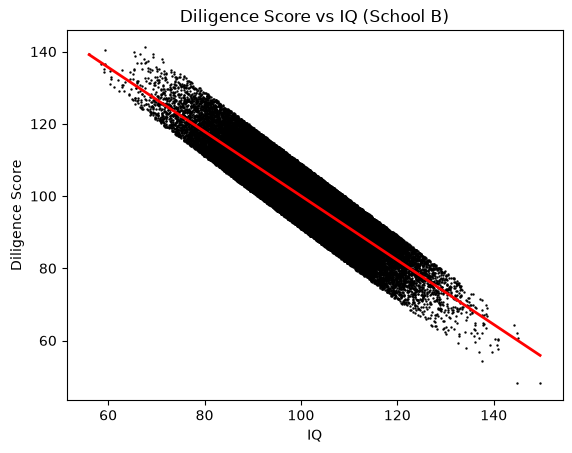

In [39]:
# Plotting the regression

# School B
x_grid = pd.DataFrame({
    "IQ": np.linspace(x.iloc[:, 0].min(), x.iloc[:, 0].max(), 200)
})

plt.scatter(x["IQ"], y, s=0.5,color="black") # Draws the individual observations 
plt.plot(x_grid["IQ"], fit.predict(x_grid), color="red",linewidth=2) # Draws the fitted regression line
plt.xlabel("IQ")
plt.ylabel("Diligence Score")
plt.title("Diligence Score vs IQ (School B)")

In [40]:
# Calculating the p-value and determining the results of the hypothesis test (using scipy)

# by default, this is a two-tailed test with H0: beta_1 = 0, so there is nothing to change for our purposes
result_b = stats.linregress(school_b["IQ"], school_b["Diligence"]) 
print("p-value:", result_b.pvalue)

p-value: 0.0


***
#### Hypothesis Test Conclusion
Therefore, like in school A, there is very strong evidence ($p-value\ll0.05$) to suggest a (negative) linear relationship between IQ and diligence in school B, enough to reject the null hypothesis. 
***

Text(0.5, 1.0, 'Histogram of Residuals From the Linear Fit (School B)')

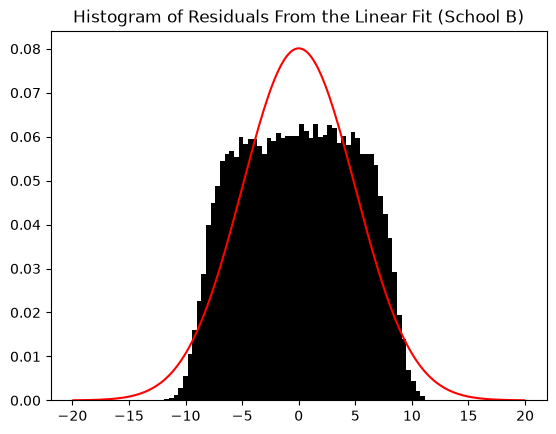

In [41]:
# Plotting the residuals (with a histogram)

fitted_values = fit.predict(x) 
residuals = y - fitted_values # e_i = yhat_i - y_i

# using the residuals' sample mean and sd for the parameters of the true normal distribution
mu = np.mean(residuals)
sigma = np.std(residuals)

grid = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 200)

plt.hist(residuals, bins=60, density=True, color="black")
plt.plot(grid, stats.norm.pdf(grid, mu, sigma), color="red")
plt.title("Histogram of Residuals From the Linear Fit (School B)")

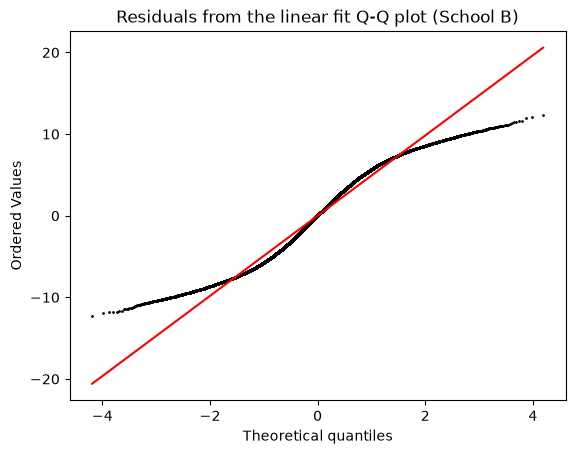

In [42]:
# Creating a Q-Q plot for the residuals. 

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Residuals from the linear fit Q-Q plot (School B)")

# Accesses scatter points component of the QQ-plot (to colour them)
points_line = plt.gca().get_lines()[0]  # index 0 is the scatter points
points_line.set_markeredgecolor('black')
points_line.set_markersize(1)

***
#### Residuals Analysis

The residuals for school B appear non-Gaussian as well, albeit for a different reason than school A. We would call this kind of distribution "light-tailed" or "platykurtic," evidenced by the histogram's wide, flat top and sudden fall-off at the tails rather than a gradual dispersion. The Q-Q plot supports this as well, in which the residuals appear as a clear s-shaped ("sigmoidal") curve around the reference line, above it on the left and below it on the right. 

***
#### School C

In [43]:
# Fitting the model (using sklearn)

# School C
print("SCHOOL C:")
x = school_c[["IQ"]]
y = school_c["Diligence"]
fit = LinearRegression()
fit.fit(x,y)

# Printing some relevant values (slope+intercept)
print("Slope (beta_1):",fit.coef_)
print("Intercept (beta_0):",fit.intercept_)

SCHOOL C:
Slope (beta_1): [-0.56171098]
Intercept (beta_0): 138.22679862140916


Text(0.5, 1.0, 'Diligence Score vs IQ (School C)')

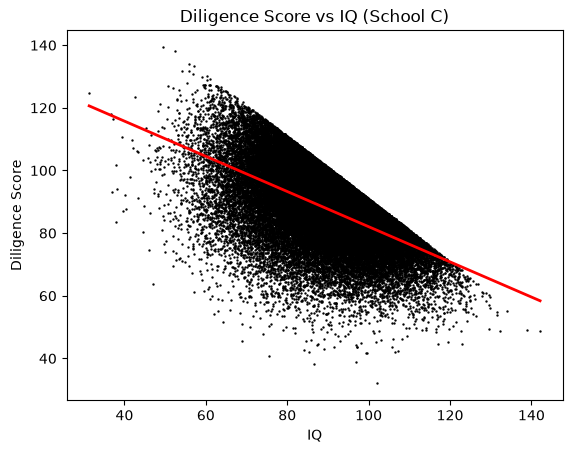

In [44]:
# Plotting the regression

# School C
x_grid = pd.DataFrame({
    "IQ": np.linspace(x.iloc[:, 0].min(), x.iloc[:, 0].max(), 200)
})

plt.scatter(x["IQ"], y, s=0.5,color="black") # Draws the individual observations 
plt.plot(x_grid["IQ"], fit.predict(x_grid), color="red",linewidth=2) # Draws the fitted regression line
plt.xlabel("IQ")
plt.ylabel("Diligence Score")
plt.title("Diligence Score vs IQ (School C)")

In [45]:
# Calculating the p-value and determining the results of the hypothesis test (using scipy)

# by default, this is a two-tailed test with H0: beta_1 = 0, so there is nothing to change for our purposes
result_c = stats.linregress(school_c["IQ"], school_c["Diligence"]) 
print("p-value:", result_c.pvalue)

p-value: 0.0


***
#### Hypothesis Test Conclusion
Once again, there is very strong evidence ($p-value\ll0.05$) to suggest a (negative) linear relationship between IQ and diligence in school C, enough to reject the null hypothesis. 
***

Text(0.5, 1.0, 'Histogram of Residuals From the Linear Fit (School C)')

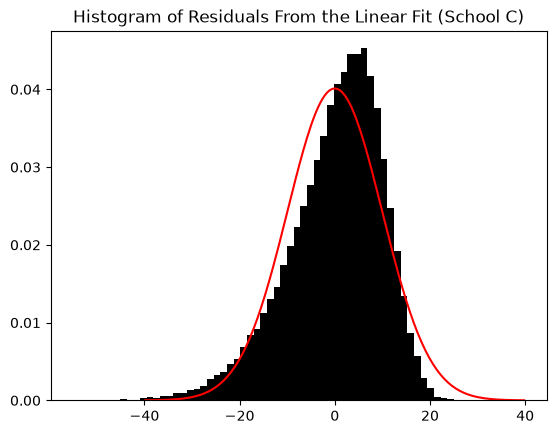

In [46]:
# Plotting the residuals (with a histogram)

fitted_values = fit.predict(x) 
residuals = y - fitted_values # e_i = yhat_i - y_i

# using the residuals' sample mean and sd for the parameters of the true normal distribution
mu = np.mean(residuals)
sigma = np.std(residuals)

grid = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 200)

plt.hist(residuals, bins=60, density=True, color="black")
plt.plot(grid, stats.norm.pdf(grid, mu, sigma), color="red")
plt.title("Histogram of Residuals From the Linear Fit (School C)")

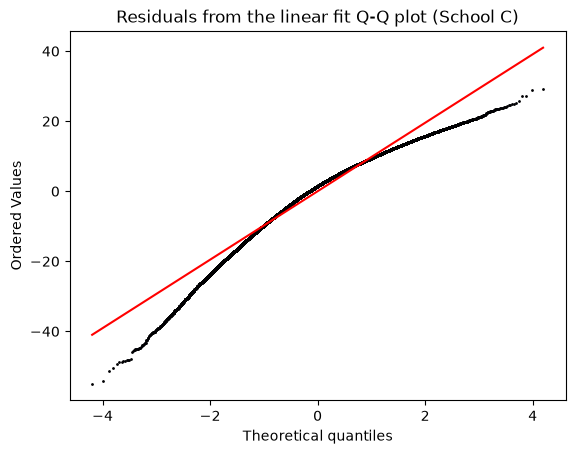

In [47]:
# Creating a Q-Q plot for the residuals.

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Residuals from the linear fit Q-Q plot (School C)")

# Accesses scatter points component of the QQ-plot (to colour them)
points_line = plt.gca().get_lines()[0]  # index 0 is the scatter points
points_line.set_markeredgecolor('black')
points_line.set_markersize(1)

***
#### Residuals Analysis

Once again, the residuals for school C appear non-Gaussian, this time for a similar reason to school A, albeit reversed. That is to say, rather that exhibiting a positive-skewness like school A, school C exhibits a negative-skewness: the residuals extend further to the left than the right and the Q-Q plot shows a downwards curve below the reference line.

***

## Part 3

***

### 3.1: Theory Question
Let $X_{i,j}$ represent the $i-th$ observation of the $j-th$ dataset where $j \in\{1,2,3\}$ and let $X_{i,p}$ represent the i-th observation of the pooled dataset.

The margin of error for the slope estimator of any linear regression when residual variance is known is:  
$MoE(\hat \beta_{1}) = z_{1-\alpha/2}\frac{\sigma}{\sqrt{SS_{xx}}} = z_{1-\alpha/2}\frac{\sigma}{\sqrt{\sum_{i=1}^n (X_{i} - \bar{X})^2}}$  where $\sigma^2$ is the residual variance and $\alpha$ is the significance level of the test.

Thus assuming the same value for $\sigma$ as the question states (and the same significance level $\alpha$), the MoEs of $\hat \beta_1$ for each dataset and the pooled dataset will be the same up to the value under the square root in the denominator  
(i.e. the MoE formulas will be the same up to the sum of squared deviations): $SS_{xx}=\sum_{i=1}^n (X_{i} - \bar{X})^2$
<br> 
</br> 
Therefore, to show that $MoE(\hat \beta_{1,p}) < MoE(\hat \beta_{1,j})$ it is sufficient to show that $SS_{xx,p} > SS_{xx,j}$ since a larger denominator will result in a smaller margin, all else being equal. Proof of that inequality is below.
<br> 
</br> 
We have:

  $SS_{xx,p} = \sum_{j=1}^{3} \sum_{i=1}^{n_{j}} (X_{i,j} - \bar X_{p})^2$ (definition of $SS_{xx}$ for the pooled dataset)
  
  $ = \sum_{j=1}^{3} \sum_{i=1}^{n_{j}} [(X_{i,j} - \bar X_{j}) + (\bar X_{j} - \bar X_{p}) ]^2$ (add and subtract $\bar X_{j}$ and rearrange terms)
  
  $ = \sum_{j=1}^{3} \sum_{i=1}^{n_{j}}(X_{i,j} - \bar X_{j})^2 + 2 \sum_{j=1}^{3} \sum_{i=1}^{n_{j}} (X_{i,j} - \bar X_{j})(\bar X_{j} - \bar X_{p}) + \sum_{j=1}^{3} \sum_{i=1}^{n_{j}}(\bar X_{j} - \bar X_{p})^2 $ (expand square and split up sums)
<br> 
</br>   

Now, stepping back and looking just at the middle sum: $2\sum_{j=1}^{3} \sum_{i=1}^{n_{j}} (X_{i,j} - \bar X_{j})(\bar X_{j} - \bar X_{p})$.  
For each j, the left bracketed expression simplifies to: $\sum_{i=1}^{n_{j}} (X_{i,j} - \bar X_{j}) = \sum_{i=1}^{n_{j}} X_{i,j} - n_{j} \bar X_{j} = \sum_{i=1}^{n_{j}} X_{i,j} - \sum_{i=1}^{n_{j}} X_{i,j} = 0$ so the entire middle sum in the original expression vanishes to 0.  

Additionally, for each j, $\sum_{i=1}^{n_{j}}(X_{i,j} - \bar X_{j})^2$, is simply the definition of $SS_{xx,j}$, which together with the middle term equalling 0, turns our original equation into:
<br> 
</br>
$SS_{xx,p} = \sum_{j=1}^{3}SS_{xx,j} + \sum_{j=1}^{3}\sum_{i=1}^{n_{j}}(\bar X_{j} - \bar X_{p})^2$
<br> 
</br>
Now the expression $\sum_{j=1}^{3}\sum_{i=1}^{n_{j}}(\bar X_{j} - \bar X_{p})^2$ is strictly non-negative, as it is the sum of squared real numbers. Moreover, the sum of all three $SS_{xx,j}$ terms is strictly greater than each $SS_{xx,j}$ taken individually, since they are all strictly positive (non-negative by the same argument as the last sum, and non-zero since we are told that each dataset contains at least two distinct $X_i$)
  
Putting this together, $\forall j \in \{1,2,3\},  SS_{xx,j} < \sum_{j=1}^{3}SS_{xx,j} \leq \sum_{j=1}^{3}SS_{xx,j} + \sum_{j=1}^{3}\sum_{i=1}^{n_{j}}(\bar X_{j} - \bar X_{p})^2 = SS_{xx,p}$

Therefore $SS_{xx,p} > SS_{xx,j}$, and thus $MoE(\hat \beta_{1,p}) < MoE(\hat \beta_{1,j})$, so the confidence interval of the pooled dataset will be strictly narrower than the confidence interval of each individual dataset.
***

### 3.2: Merged Dataset Analysis


In [48]:
# Combine three dataframes into one large dataframe
merged_df = pd.concat([school_a, school_b, school_c], ignore_index=True)


# Fitting the model (using sklearn)

print("MERGED DATASET:")
x = merged_df[["IQ"]]
y = merged_df["Diligence"]
fit = LinearRegression()
fit.fit(x,y)

# Printing some relevant values (slope+intercept)
print("Slope (beta_1):",fit.coef_)
print("Intercept (beta_0):",fit.intercept_)

MERGED DATASET:
Slope (beta_1): [0.00066073]
Intercept (beta_0): 99.94581809709764


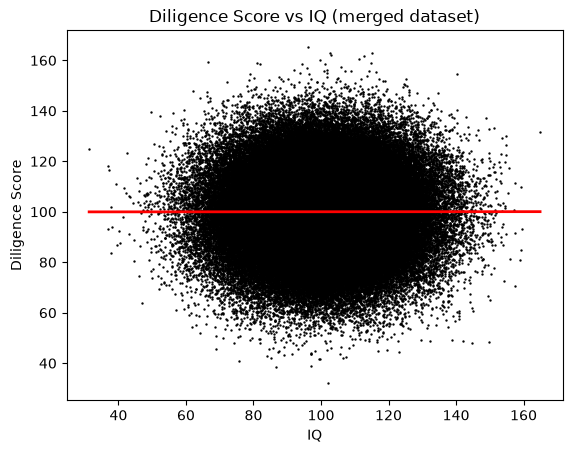

In [49]:
# Plotting the regression 

x_grid = pd.DataFrame({
    "IQ": np.linspace(x.iloc[:, 0].min(), x.iloc[:, 0].max(), 200)
})

plt.scatter(x["IQ"], y, s=0.5,color="black") # Draws the individual observations 
plt.plot(x_grid["IQ"], fit.predict(x_grid), color="red",linewidth=2) # Draws the fitted regression line
plt.xlabel("IQ")
plt.ylabel("Diligence Score")
plt.title("Diligence Score vs IQ (merged dataset)")
plt.show()

In [50]:
# Calculating the p-value and determining the results of the hypothesis test (using scipy)

# by default, this is a two-tailed test with H0: beta_1 = 0, so there is nothing to change for our purposes
result_merged = stats.linregress(merged_df["IQ"], merged_df["Diligence"]) 
print("p-value:", result_merged.pvalue)

p-value: 0.7978868742393707


#### Hypothesis Test Conclusion

With the merged datasets, the $p-value$ came to be approximately 0.798, which by any standard choice of $\alpha$ (e.g. 0.05), means we should fail to reject the null hypothesis. That is to say, there is insufficient evidence to suggest a linear relationship between IQ and diligence within the three schools.

Text(0.5, 1.0, 'Histogram of Residuals From the Linear Fit (merged dataset)')

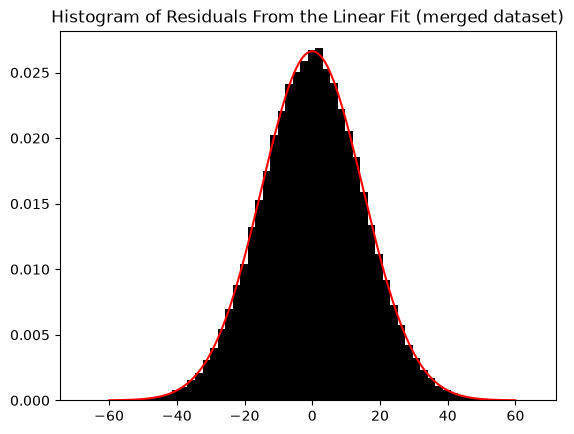

In [51]:
# Plotting the residuals (with a histogram)

fitted_values = fit.predict(x) 
residuals = y - fitted_values # e_i = yhat_i - y_i

# using the residuals' sample mean and sd for the parameters of the true normal distribution
mu = np.mean(residuals)
sigma = np.std(residuals)

grid = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 200)

plt.hist(residuals, bins=60, density=True, color="black")
plt.plot(grid, stats.norm.pdf(grid, mu, sigma), color="red")
plt.title("Histogram of Residuals From the Linear Fit (merged dataset)")

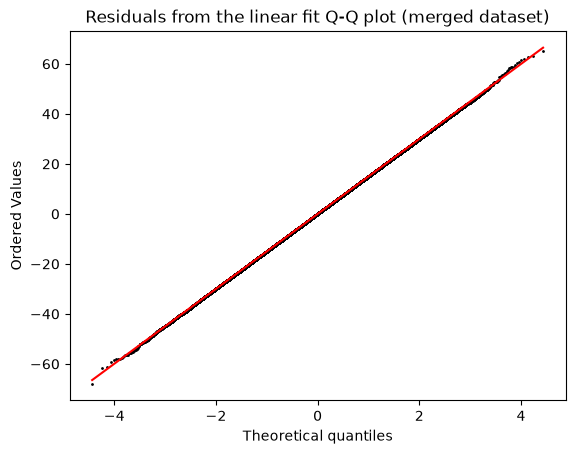

In [52]:
# Creating a Q-Q plot for the residuals.

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Residuals from the linear fit Q-Q plot (merged dataset)")

# Accesses scatter points component of the QQ-plot (to colour them)
points_line = plt.gca().get_lines()[0]  # index 0 is the scatter points
points_line.set_markeredgecolor('black')
points_line.set_markersize(1)

#### Residuals Analysis

With the merged datasets, the distribution of residuals now strongly appears Gaussian, with the histogram and Q-Q Plot following the theoretical distribution almost exactly. 

***

### 3.3: Explanation of Apparent Conflict

The apparent contradiction is that, although each dataset individually showed a negative linear relationship between diligence and IQ, the pooled dataset showed no linear relationship.

This is an example of Simpson’s Paradox. The key to understanding why it appears here is the differing admissions criteria across the three universities: “The first university, A, is the most selective. The second, B, is less selective. The third, C, is not selective.”

The three universities admit students at different levels of selectivity, meaning they are not truly representative of the same population, and furthermore, it is likely the case that both IQ and diligence contribute to a student's chance of being admitted to a given university. 

Among students at university A, for instance, someone with a very high IQ might be admitted despite relatively low diligence, while a student with a lower IQ might need exceptionally high diligence to compensate. A similar pattern could occur at University B, albeit around a lower overall admissions requirement, and again at University C, around an even lower threshold. 

As a result, IQ and diligence can appear negatively related within each university even when no such relationship exists in the population as a whole.

The following is a toy example demonstrating the same phenomenon:

Dataset 1:
|X|Y|
|:--|:--|
|1|10|
|2|9|

Dataset 2:
|X|Y|
|:--|:--|
|5|15|
|6|14|

Indeed, this is an even more extreme example, since rather than going from a negative relationship individually to no relationship in aggregate, it goes from a negative relationship individually to a positive relationship, though the underlying principle is the same.

Below are some plots of this data:

In [53]:
# Creating the toy datasets

data1 = {
    "X": [1,2],
    "Y": [10,9],
}

data2 = {
    "X": [5,6],
    "Y": [15,14],
}

df_1 = pd.DataFrame(data1)
df_2 = pd.DataFrame(data2)
df_3 =  pd.concat([df_1, df_2], ignore_index=True)


Text(0.5, 1.0, 'X vs Y (toy dataset 1)')

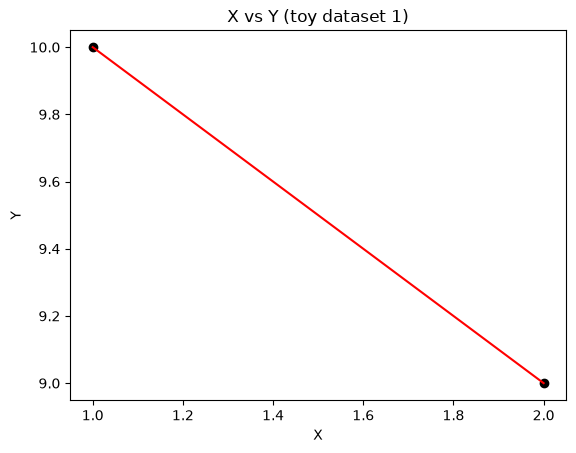

In [54]:
# Plotting toy dataset 1

x = df_1[["X"]]
y = df_1["Y"]
fit = LinearRegression()
fit.fit(x,y)

x_grid = pd.DataFrame({
    "X": np.linspace(x.iloc[:, 0].min(), x.iloc[:, 0].max(), 200)
})

plt.scatter(x["X"], y,color="black") 
plt.plot(x_grid["X"], fit.predict(x_grid), color="red") 
plt.xlabel("X")
plt.ylabel("Y")
plt.title("X vs Y (toy dataset 1)")

Text(0.5, 1.0, 'X vs Y (toy dataset 2)')

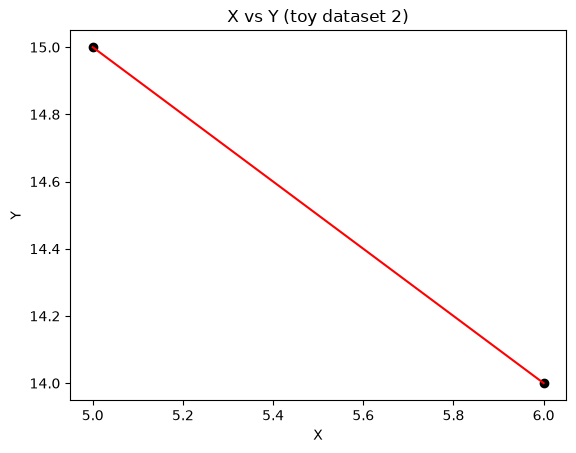

In [55]:
# Plotting toy dataset 2

x = df_2[["X"]]
y = df_2["Y"]
fit = LinearRegression()
fit.fit(x,y)

x_grid = pd.DataFrame({
    "X": np.linspace(x.iloc[:, 0].min(), x.iloc[:, 0].max(), 200)
})

plt.scatter(x["X"], y,color="black") 
plt.plot(x_grid["X"], fit.predict(x_grid), color="red") 
plt.xlabel("X")
plt.ylabel("Y")
plt.title("X vs Y (toy dataset 2)")

Text(0.5, 1.0, 'X vs Y (merged toy dataset)')

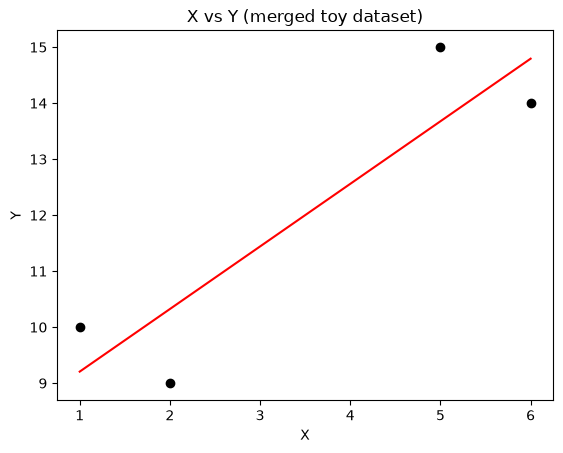

In [56]:
# Plotting merged toy dataset

x = df_3[["X"]]
y = df_3["Y"]
fit = LinearRegression()
fit.fit(x,y)

x_grid = pd.DataFrame({
    "X": np.linspace(x.iloc[:, 0].min(), x.iloc[:, 0].max(), 200)
})

plt.scatter(x["X"], y,color="black") 
plt.plot(x_grid["X"], fit.predict(x_grid), color="red") 
plt.xlabel("X")
plt.ylabel("Y")
plt.title("X vs Y (merged toy dataset)")